<a href="https://colab.research.google.com/github/ASHIA08/stylegan_reimplementation/blob/master/MOVIE_RECOMMENDATION_SYSTEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
movie_df = pd.read_csv('movies.csv')
movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movie_df.shape

(9742, 3)

In [6]:
movie_df_ratings = pd.read_csv('ratings.csv')
movie_df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
movie_df_ratings.shape

(100836, 4)

In [8]:
movie_df.drop(['genres'],inplace=True,axis=1)
movie_df.head()

,movieId,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3,Grumpier Old Men (1995)
3,4,Waiting to Exhale (1995)
4,5,Father of the Bride Part II (1995)


In [9]:
movie_df_ratings.drop(['timestamp'],inplace=True,axis=1)
movie_df_ratings.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [10]:
merged_movie_df = pd.merge(movie_df,movie_df_ratings,on='movieId')
merged_movie_df.head()

,movieId,title,userId,rating
0,1,Toy Story (1995),1,4.0
1,1,Toy Story (1995),5,4.0
2,1,Toy Story (1995),7,4.5
3,1,Toy Story (1995),15,2.5
4,1,Toy Story (1995),17,4.5


In [12]:
merged_movie_df.groupby('title').describe()

movieId                           \
                                            count      mean  std       min   
title                                                                        
'71 (2014)                                    1.0  117867.0  NaN  117867.0   
'Hellboy': The Seeds of Creation (2004)       1.0   97757.0  NaN   97757.0   
'Round Midnight (1986)                        2.0   26564.0  0.0   26564.0   
'Salem's Lot (2004)                           1.0   27751.0  NaN   27751.0   
'Til There Was You (1997)                     2.0     779.0  0.0     779.0   
...                                           ...       ...  ...       ...   
eXistenZ (1999)                              22.0    2600.0  0.0    2600.0   
xXx (2002)                                   24.0    5507.0  0.0    5507.0   
xXx: State of the Union (2005)                5.0   33158.0  0.0   33158.0   
¡Three Amigos! (1986)                        26.0    2478.0  0.0    2478.0   
À nous la liberté (Freedom for Us) (1931)     1.0    5560.0  NaN    5560.0   

                                                                         \
                                                25%       50%       75%   
title                                                                     
'71 (2014)                                 117867.0  117867.0  117867.0   
'Hellboy': The Seeds of Creation (2004)     97757.0   97757.0   97757.0   
'Round Midnight (1986)                      26564.0   26564.0   26564.0   
'Salem's Lot (2004)                         27751.0   27751.0   27751.0   
'Til There Was You (1997)                     779.0     779.0     779.0   
...                                             ...       ...       ...   
eXistenZ (1999)                              2600.0    2600.0    2600.0   
xXx (2002)                                   5507.0    5507.0    5507.0   
xXx: State of the Union (2005)              33158.0   33158.0   33158.0   
¡Three Amigos! (1986)                        2478.0    2478.0    2478.0   
À nous la liberté (Freedom for Us) (1931)    5560.0    5560.0    5560.0   

                                                    userId              ...  \
                                                max  count        mean  ...   
title                                                                   ...   
'71 (2014)                                 117867.0    1.0  610.000000  ...   
'Hellboy': The Seeds of Creation (2004)     97757.0    1.0  332.000000  ...   
'Round Midnight (1986)                      26564.0    2.0  354.500000  ...   
'Salem's Lot (2004)                         27751.0    1.0  345.000000  ...   
'Til There Was You (1997)                     779.0    2.0  229.000000  ...   
...                                             ...    ...         ...  ...   
eXistenZ (1999)                              2600.0   22.0  389.954545  ...   
xXx (2002)                                   5507.0   24.0  272.916667  ...   
xXx: State of the Union (2005)              33158.0    5.0  386.000000  ...   
¡Three Amigos! (1986)                        2478.0   26.0  279.807692  ...   
À nous la liberté (Freedom for Us) (1931)    5560.0    1.0  527.000000  ...   

                                                         rating            \
                                              75%    max  count      mean   
title                                                                       
'71 (2014)                                 610.00  610.0    1.0  4.000000   
'Hellboy': The Seeds of Creation (2004)    332.00  332.0    1.0  4.000000   
'Round Midnight (1986)                     365.75  377.0    2.0  3.500000   
'Salem's Lot (2004)                        345.00  345.0    1.0  5.000000   
'Til There Was You (1997)                  287.00  345.0    2.0  4.000000   
...                                           ...    ...    ...       ...   
eXistenZ (1999)                            509.25  608.0   22.0  3.863636   
xXx (2002)           

In [13]:
merged_movie_df.groupby('title')['rating'].mean().head()

,rating
title,
'71 (2014),4.0
'Hellboy': The Seeds of Creation (2004),4.0
'Round Midnight (1986),3.5
'Salem's Lot (2004),5.0
'Til There Was You (1997),4.0


In [14]:
merged_movie_df.groupby('title')['rating'].mean().sort_values(ascending=False).head()

,rating
title,
Karlson Returns (1970),5.0
Zeitgeist: Moving Forward (2011),5.0
"Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)",5.0
Dragons: Gift of the Night Fury (2011),5.0
12 Angry Men (1997),5.0


In [15]:
merged_movie_df.groupby('title')['rating'].mean().sort_values(ascending=False).head()

,rating
title,
Karlson Returns (1970),5.0
Zeitgeist: Moving Forward (2011),5.0
"Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)",5.0
Dragons: Gift of the Night Fury (2011),5.0
12 Angry Men (1997),5.0


In [16]:
merged_movie_df.groupby('title')['rating'].count().sort_values(ascending=False).head()


,rating
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278


In [17]:
movie_rating_mean_count=pd.DataFrame(columns=['rating_mean','rating_count'])

In [18]:
movie_rating_mean_count['rating_mean']=merged_movie_df.groupby('title')['rating'].mean()
movie_rating_mean_count['rating_count']=merged_movie_df.groupby('title')['rating'].count()

In [19]:
movie_rating_mean_count.head()

,rating_mean,rating_count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


Text(0.5, 0, 'Rating')

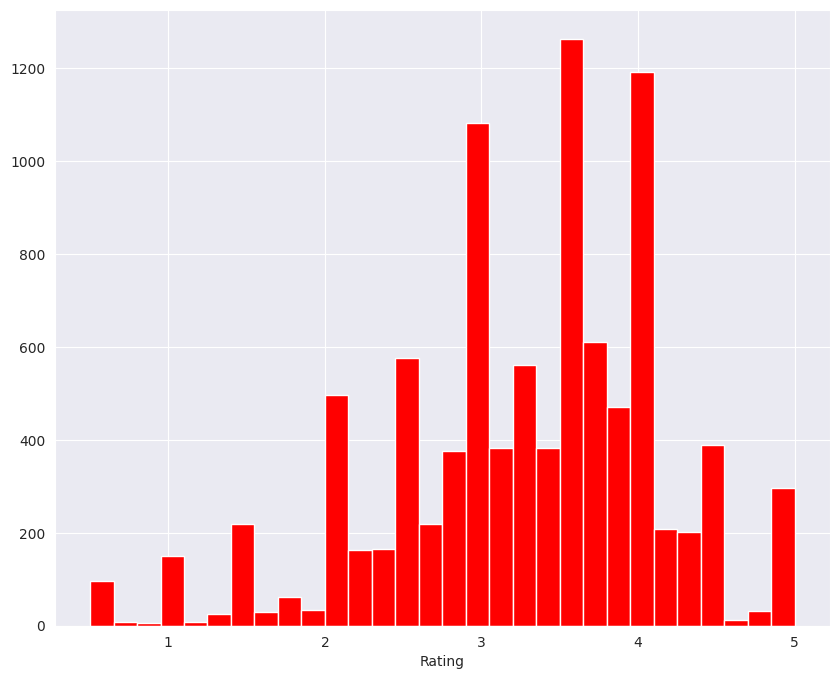

In [21]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
movie_rating_mean_count['rating_mean'].hist(bins=30,color='red')
plt.xlabel('Rating')

Text(0.5, 0, 'Rating Count')

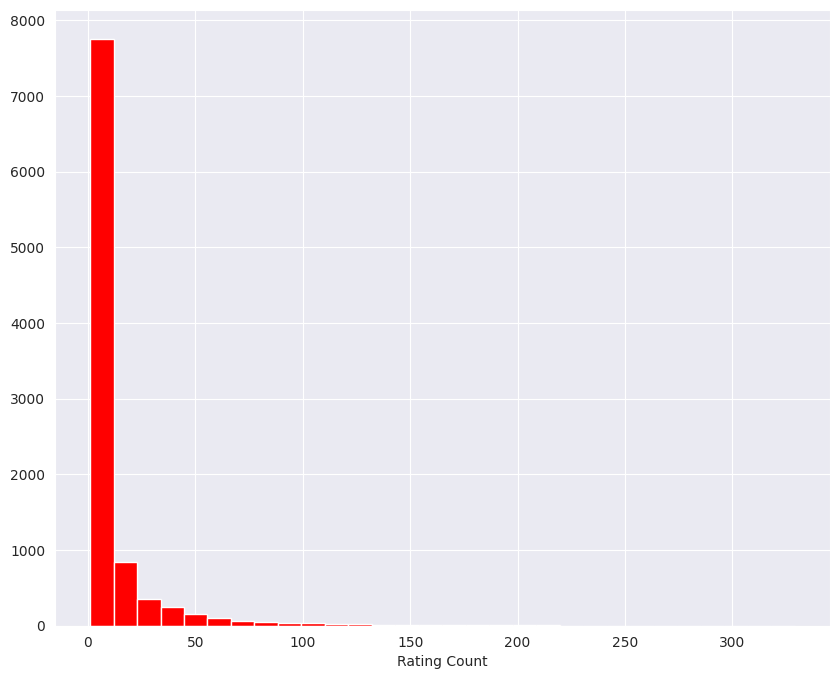

In [22]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
movie_rating_mean_count['rating_count'].hist(bins=30,color='red')
plt.xlabel('Rating Count')

<Axes: xlabel='rating_mean', ylabel='rating_count'>

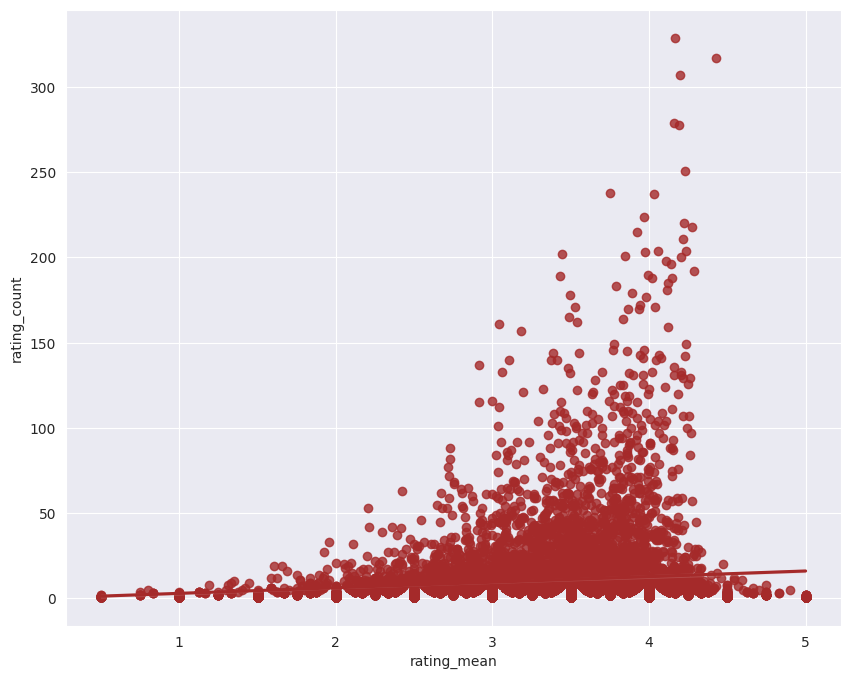

In [24]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
sns.regplot(x='rating_mean',y='rating_count',data=movie_rating_mean_count,color="brown")

In [25]:
movie_rating_mean_count.sort_values('rating_count',ascending=False).head()

,rating_mean,rating_count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278


In [26]:
user_movie_rating = merged_movie_df.pivot_table(index='userId',columns='title',values='rating')
user_movie_rating.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
user_movie_rating.shape

(610, 9719)

In [33]:
pulp_fiction_ratings = user_movie_rating['Pulp Fiction (1994)']


In [38]:
pulp_fiction_correlation=pd.DataFrame(user_movie_rating.corrwith(pulp_fiction_ratings),columns=['pf_corr'])


In [39]:
pulp_fiction_correlation.sort_values('pf_corr',ascending=False).head()

,pf_corr
title,
10 Cent Pistol (2015),1.0
2 Guns (2013),1.0
Max Dugan Returns (1983),1.0
Chasers (1994),1.0
Written on the Wind (1956),1.0


In [40]:
pulp_fiction_correlation=pulp_fiction_correlation.join(movie_rating_mean_count['rating_count'])
pulp_fiction_correlation.head()

,pf_corr,rating_count
title,,
'71 (2014),NaN,1
'Hellboy': The Seeds of Creation (2004),NaN,1
'Round Midnight (1986),NaN,2
'Salem's Lot (2004),NaN,1
'Til There Was You (1997),NaN,2


In [41]:
  pulp_fiction_correlation.dropna(inplace=True)

In [42]:
pulp_fiction_correlation.sort_values('pf_corr',ascending=False).head()

,pf_corr,rating_count
title,,
10 Cent Pistol (2015),1.0,2
2 Guns (2013),1.0,3
Max Dugan Returns (1983),1.0,4
Chasers (1994),1.0,2
Written on the Wind (1956),1.0,2


In [44]:
pulp_fiction_correlation_50=pulp_fiction_correlation[pulp_fiction_correlation['rating_count']>50]

pulp_fiction_correlation_50.sort_values("pf_corr",ascending=False).head()

,pf_corr,rating_count
title,,
Pulp Fiction (1994),1.000000,307
"Wolf of Wall Street, The (2013)",0.579915,54
Fight Club (1999),0.543465,218
Kill Bill: Vol. 1 (2003),0.504147,131
Interstellar (2014),0.503411,73


In [45]:
# Get the ratings of the top similar users
# We'll use the top 10 most similar users for recommendations
top_similar_users = user_similarity_df.head(10)
similar_user_ratings = user_movie_rating.loc[top_similar_users.index]

# Multiply the ratings of similar users by their similarity score
# We need to align the similarity scores with the columns of the ratings DataFrame
weighted_ratings = similar_user_ratings.mul(top_similar_users['correlation'], axis=0)

# Calculate the sum of weighted ratings and the sum of similarity scores for each movie
weighted_sum = weighted_ratings.sum(axis=0)
similarity_sum = top_similar_users['correlation'].sum()

# Calculate the weighted average rating for each movie
recommended_movies = weighted_sum / similarity_sum

# Filter out movies already rated by the target user
recommended_movies = recommended_movies.drop(target_user_ratings.index, errors='ignore')

# Sort the recommended movies by their weighted average rating
recommended_movies = recommended_movies.sort_values(ascending=False)

print(f"Top 10 movie recommendations for user {target_user_id}:")
display(recommended_movies.head(10))

Top 10 movie recommendations for user 1:


,0
title,
'71 (2014),NaN
'Hellboy': The Seeds of Creation (2004),NaN
'Round Midnight (1986),NaN
'Salem's Lot (2004),NaN
'Til There Was You (1997),NaN
'Tis the Season for Love (2015),NaN
"'burbs, The (1989)",NaN
'night Mother (1986),NaN
(500) Days of Summer (2009),NaN


In [46]:
# Get the most popular movies based on rating count
most_popular_movies = movie_rating_mean_count.sort_values('rating_count', ascending=False).head(10)

print("Top 10 most popular movies:")
display(most_popular_movies)

print(f"\nTop 10 movie recommendations for user {target_user_id}:")
display(recommended_movies.head(10))

Top 10 most popular movies:


,rating_mean,rating_count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224



Top 10 movie recommendations for user 1:


,0
title,
'71 (2014),NaN
'Hellboy': The Seeds of Creation (2004),NaN
'Round Midnight (1986),NaN
'Salem's Lot (2004),NaN
'Til There Was You (1997),NaN
'Tis the Season for Love (2015),NaN
"'burbs, The (1989)",NaN
'night Mother (1986),NaN
(500) Days of Summer (2009),NaN
